# Reprodução da Lei de Zipf nos municípios do Ceará

Este notebook reproduz, em Python, os resultados do artigo sobre a distribuição populacional dos 184 municípios cearenses. Ele baixa os dados oficiais do IBGE, organiza o ranking, calcula o expoente de Zipf $q$, o coeficiente $R^2$, o teste da inclinação, o índice de Gini e gera o mapa e o gráfico rank-size.

**Como usar no VS Code:** abra este arquivo, escolha o kernel do ambiente virtual criado para o projeto e execute as células na ordem, usando **Shift + Enter**.

## 1. Preparação do ambiente

No terminal PowerShell do VS Code, dentro da pasta do projeto, execute:

```powershell
py -3.10 -m venv zipf-env
Set-ExecutionPolicy -Scope Process -ExecutionPolicy Bypass
.\zipf-env\Scripts\Activate.ps1
python -m pip install --upgrade pip
python -m pip install numpy pandas matplotlib scipy jupyter ipykernel
python -m ipykernel install --user --name zipf-env --display-name "Python (zipf-env)"
```

Depois, no canto superior direito do notebook, clique em **Selecionar Kernel** e escolha **Python (zipf-env)**. A célula abaixo também instala ou confirma as bibliotecas no kernel selecionado.

In [14]:
%pip install -q numpy pandas matplotlib scipy

/home/davvi/Programing/Unifor/ciencia_cidades/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


## 2. Importações e pastas

Os arquivos baixados serão guardados em `data` e as saídas reproduzidas em `notebook_output`.

In [15]:
import gzip
import json
import math
from pathlib import Path
from urllib.request import urlopen

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.collections import PatchCollection
from matplotlib.patches import Polygon as MplPolygon
from scipy import stats

ROOT = Path.cwd()
DATA = ROOT / 'data'
OUTPUT = ROOT / 'notebook_output'
DATA.mkdir(exist_ok=True)
OUTPUT.mkdir(exist_ok=True)

print('Pasta atual:', ROOT)
print('Python e bibliotecas carregados com sucesso.')

Pasta atual: /home/davvi/Programing/Unifor/ciencia_cidades
Python e bibliotecas carregados com sucesso.


## 3. Coleta dos dados oficiais do IBGE

A primeira URL consulta a tabela SIDRA 4709, variável 93, referente à população residente no Censo 2022. `N6[N3[23]]` significa municípios pertencentes ao Ceará, cujo código é 23. A segunda URL baixa a malha municipal em GeoJSON.

In [16]:
POP_URL = (
    'https://servicodados.ibge.gov.br/api/v3/agregados/4709/periodos/2022/'
    'variaveis/93?localidades=N6[N3[23]]'
)
MAP_URL = (
    'https://servicodados.ibge.gov.br/api/v3/malhas/estados/23?'
    'formato=application/vnd.geo+json&qualidade=minima&intrarregiao=municipio'
)

population_path = DATA / 'ibge_populacao_ceara_2022.json'
map_path = DATA / 'ibge_malha_municipal_ceara.geojson'

def descompactar_se_gzip(conteudo):
    # A API do IBGE pode devolver o corpo compactado em gzip (bytes iniciais 1f 8b).
    # O urlopen não descompacta sozinho, então fazemos isso aqui.
    return gzip.decompress(conteudo) if conteudo[:2] == b'\x1f\x8b' else conteudo

def baixar_se_necessario(url, destino):
    if destino.exists():
        conteudo = destino.read_bytes()
        if conteudo[:2] == b'\x1f\x8b':
            # Arquivo salvo por uma versão anterior do notebook, ainda compactado.
            destino.write_bytes(descompactar_se_gzip(conteudo))
            print(f'Arquivo já existente (descompactado): {destino.name}')
        else:
            print(f'Arquivo já existente: {destino.name}')
        return
    print(f'Baixando {destino.name}...')
    with urlopen(url, timeout=90) as resposta:
        destino.write_bytes(descompactar_se_gzip(resposta.read()))
    print('Download concluído.')

baixar_se_necessario(POP_URL, population_path)
baixar_se_necessario(MAP_URL, map_path)

Arquivo já existente: ibge_populacao_ceara_2022.json
Arquivo já existente (descompactado): ibge_malha_municipal_ceara.geojson


## 4. Tratamento, ranking e logaritmos

As cidades são ordenadas da maior para a menor população. Em seguida, calculamos $x=\log_{10}(rank)$ e $y=\log_{10}(população)$.

In [17]:
raw = json.loads(population_path.read_text(encoding='utf-8'))
series = raw[0]['resultados'][0]['series']

rows = []
for item in series:
    localidade = item['localidade']
    rows.append({
        'codigo_ibge': localidade['id'],
        'municipio': localidade['nome'].removesuffix(' - CE'),
        'populacao': int(item['serie']['2022']),
    })

df = pd.DataFrame(rows).sort_values('populacao', ascending=False).reset_index(drop=True)
df['rank'] = np.arange(1, len(df) + 1)
df['log10_rank'] = np.log10(df['rank'])
df['log10_populacao'] = np.log10(df['populacao'])

print('Número de municípios:', len(df))
display(df.head(10))

Número de municípios: 184


,codigo_ibge,municipio,populacao,rank,log10_rank,log10_populacao
0,2304400,Fortaleza,2428708,1,0.000000,6.385375
1,2303709,Caucaia,355679,2,0.301030,5.551058
2,2307304,Juazeiro do Norte,286120,3,0.477121,5.456548
3,2307650,Maracanaú,234509,4,0.602060,5.370160
4,2312908,Sobral,203023,5,0.698970,5.307545
5,2306405,Itapipoca,131123,6,0.778151,5.117679
6,2304202,Crato,131050,7,0.845098,5.117437
7,2307700,Maranguape,105093,8,0.903090,5.021574
8,2305506,Iguatu,98064,9,0.954243,4.991510
9,2311306,Quixadá,84168,10,1.000000,4.925147


## 5. Cálculo manual da regressão, de $q$ e de $R^2$

A inclinação é calculada por $\hat{\beta}=S_{xy}/S_{xx}$. Como o modelo é $y=\alpha-qx$, temos $q=-\hat{\beta}$. O coeficiente de determinação é $R^2=1-SSE/SST$. A função também calcula o intervalo de confiança e testa se a inclinação é igual a -1.

In [18]:
def ajustar_rank_size(amostra):
    x = amostra['log10_rank'].to_numpy()
    y = amostra['log10_populacao'].to_numpy()

    x_media = x.mean()
    y_media = y.mean()
    sxx = np.sum((x - x_media) ** 2)
    sxy = np.sum((x - x_media) * (y - y_media))
    beta = sxy / sxx
    intercepto = y_media - beta * x_media
    q = -beta

    y_estimado = intercepto + beta * x
    sse = np.sum((y - y_estimado) ** 2)
    sst = np.sum((y - y_media) ** 2)
    r2 = 1 - sse / sst

    n = len(amostra)
    graus_liberdade = n - 2
    erro_padrao_beta = np.sqrt((sse / graus_liberdade) / sxx)
    t_critico = stats.t.ppf(0.975, graus_liberdade)
    ic_inferior = beta - t_critico * erro_padrao_beta
    ic_superior = beta + t_critico * erro_padrao_beta
    t_zipf = (beta - (-1)) / erro_padrao_beta
    p_zipf = 2 * stats.t.sf(abs(t_zipf), graus_liberdade)

    return {
        'n': n, 'media_x': x_media, 'media_y': y_media,
        'Sxx': sxx, 'Sxy': sxy, 'intercepto': intercepto,
        'beta': beta, 'q': q, 'SSE': sse, 'SST': sst, 'R2': r2,
        'erro_padrao_beta': erro_padrao_beta,
        'IC95_inferior': ic_inferior, 'IC95_superior': ic_superior,
        't_teste_beta_menos_1': t_zipf, 'p_teste_beta_menos_1': p_zipf,
    }

resultado_184 = ajustar_rank_size(df)
resultado_top20 = ajustar_rank_size(df.head(20))

## 6. Resultados das duas amostras

O primeiro modelo usa todos os 184 municípios. O segundo usa somente os 20 maiores.

In [19]:
comparacao = pd.DataFrame([
    {'amostra': '184 municípios', **resultado_184},
    {'amostra': '20 maiores', **resultado_top20},
])[['amostra', 'n', 'Sxx', 'Sxy', 'beta', 'q', 'SSE', 'SST', 'R2',
    'IC95_inferior', 'IC95_superior', 'p_teste_beta_menos_1']]

display(comparacao.round(6))
print(f"184 municípios: q = {resultado_184['q']:.4f} e R² = {resultado_184['R2']:.4f}")
print(f"20 maiores:     q = {resultado_top20['q']:.4f} e R² = {resultado_top20['R2']:.4f}")

,amostra,n,Sxx,Sxy,beta,q,SSE,SST,R2,IC95_inferior,IC95_superior,p_teste_beta_menos_1
0,184 municípios,184,31.271361,-28.191121,-0.901500,0.901500,1.613769,27.028054,0.940293,-0.934724,-0.868275,0.000000
1,20 maiores,20,2.366990,-2.339318,-0.988309,0.988309,0.282747,2.594717,0.891030,-1.159458,-0.817160,0.887483


184 municípios: q = 0.9015 e R² = 0.9403
20 maiores:     q = 0.9883 e R² = 0.8910


## 7. Conferência numérica do cálculo principal

Esta célula mostra explicitamente as substituições usadas no artigo. Pequenas diferenças na última casa decimal podem ocorrer apenas por arredondamento de exibição.

In [20]:
r = resultado_184
print(f"β = Sxy / Sxx = {r['Sxy']:.4f} / {r['Sxx']:.4f} = {r['beta']:.4f}")
print(f"q = -β = {r['q']:.4f}")
print(f"R² = 1 - SSE/SST = 1 - {r['SSE']:.4f}/{r['SST']:.4f} = {r['R2']:.4f}")

β = Sxy / Sxx = -28.1911 / 31.2714 = -0.9015
q = -β = 0.9015
R² = 1 - SSE/SST = 1 - 1.6138/27.0281 = 0.9403


## 8. Estatísticas auxiliares

Calculamos a participação de Fortaleza, a razão Fortaleza/Caucaia e o Gini da população municipal.

In [21]:
def gini(valores):
    valores = np.sort(np.asarray(valores, dtype=float))
    n = valores.size
    return (2 * np.sum(np.arange(1, n + 1) * valores) / (n * valores.sum())) - (n + 1) / n

pop_total = int(df['populacao'].sum())
fortaleza = df.iloc[0]
caucaia = df.iloc[1]
participacao = 100 * fortaleza['populacao'] / pop_total
razao = fortaleza['populacao'] / caucaia['populacao']
gini_pop = gini(df['populacao'])

print(f'População somada dos municípios: {pop_total:,}'.replace(',', '.'))
print(f'Participação de Fortaleza: {participacao:.2f}%')
print(f'Razão Fortaleza/Caucaia: {razao:.2f}')
print(f'Gini das populações municipais: {gini_pop:.4f}')

População somada dos municípios: 8.794.957
Participação de Fortaleza: 27.61%
Razão Fortaleza/Caucaia: 6.83
Gini das populações municipais: 0.6172


## 9. Mapa e gráfico da Lei de Zipf

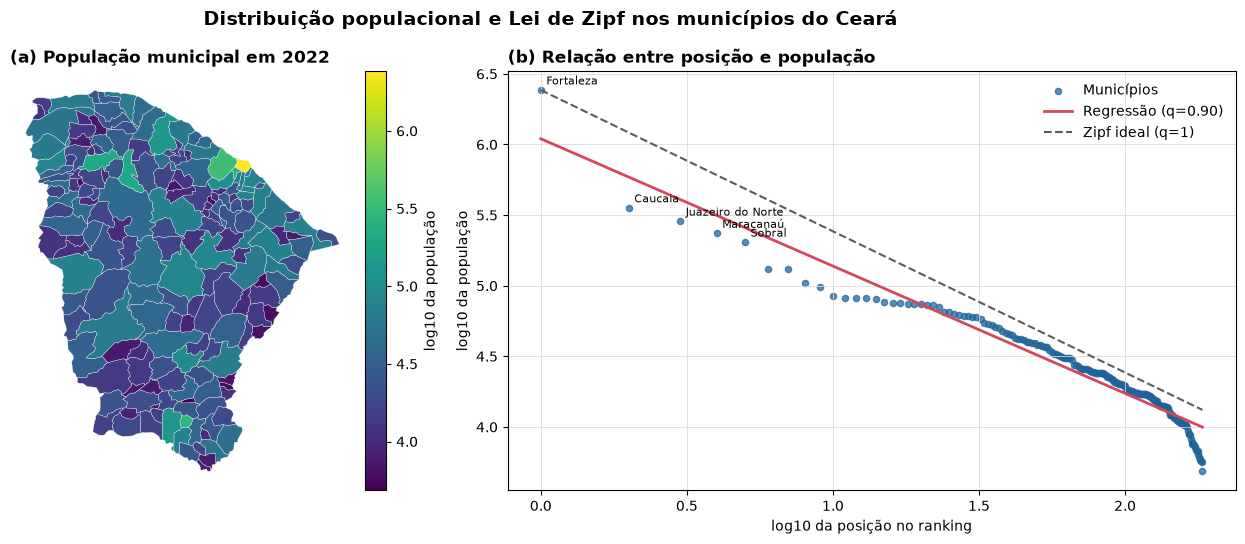

In [22]:
def geometria_para_poligonos(geometria):
    patches = []
    if geometria['type'] == 'Polygon':
        poligonos = [geometria['coordinates']]
    elif geometria['type'] == 'MultiPolygon':
        poligonos = geometria['coordinates']
    else:
        return patches
    for poligono in poligonos:
        if poligono and len(poligono[0]) >= 3:
            patches.append(MplPolygon(np.asarray(poligono[0]), closed=True))
    return patches

geo = json.loads(map_path.read_text(encoding='utf-8'))
pop_por_codigo = df.set_index('codigo_ibge')['populacao'].to_dict()
fig, (ax_mapa, ax_zipf) = plt.subplots(1, 2, figsize=(14, 5.5),
    gridspec_kw={'width_ratios': [0.9, 1.25]})

patches, valores = [], []
for feature in geo['features']:
    codigo = feature['properties']['codarea']
    populacao = pop_por_codigo.get(codigo)
    if populacao is None:
        continue
    partes = geometria_para_poligonos(feature['geometry'])
    patches.extend(partes)
    valores.extend([math.log10(populacao)] * len(partes))

colecao = PatchCollection(patches, cmap='viridis', edgecolor='white', linewidth=0.22)
colecao.set_array(np.asarray(valores))
ax_mapa.add_collection(colecao)
ax_mapa.autoscale_view()
ax_mapa.set_aspect('equal')
ax_mapa.axis('off')
ax_mapa.set_title('(a) População municipal em 2022', loc='left', fontweight='bold')
fig.colorbar(colecao, ax=ax_mapa, fraction=0.046, pad=0.02, label='log10 da população')

x = df['log10_rank'].to_numpy()
y = df['log10_populacao'].to_numpy()
x_linha = np.linspace(0, x.max(), 200)
ajustada = resultado_184['intercepto'] + resultado_184['beta'] * x_linha
zipf_ideal = y[0] - x_linha
ax_zipf.scatter(x, y, s=20, alpha=0.72, color='#20639B', label='Municípios')
ax_zipf.plot(x_linha, ajustada, color='#D1495B', linewidth=2,
    label=f"Regressão (q={resultado_184['q']:.2f})")
ax_zipf.plot(x_linha, zipf_ideal, '--', color='#5B5B5B', label='Zipf ideal (q=1)')
for _, linha in df.head(5).iterrows():
    ax_zipf.annotate(linha['municipio'], (linha['log10_rank'], linha['log10_populacao']),
                     xytext=(4, 4), textcoords='offset points', fontsize=8)
ax_zipf.set_title('(b) Relação entre posição e população', loc='left', fontweight='bold')
ax_zipf.set_xlabel('log10 da posição no ranking')
ax_zipf.set_ylabel('log10 da população')
ax_zipf.grid(True, color='#D9D9D9', linewidth=0.55)
ax_zipf.legend(frameon=False)
fig.suptitle('Distribuição populacional e Lei de Zipf nos municípios do Ceará',
             fontsize=14, fontweight='bold')
fig.tight_layout()
fig.savefig(OUTPUT / 'figura_zipf_ceara_reproduzida.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Exportação dos resultados

In [23]:
df.to_csv(OUTPUT / 'municipios_ceara_populacao_2022.csv', index=False, encoding='utf-8-sig')
comparacao.to_csv(OUTPUT / 'resultados_regressao.csv', index=False, encoding='utf-8-sig')

resumo = {
    'fonte': 'IBGE, Censo Demográfico 2022, SIDRA, tabela 4709, variável 93',
    'numero_municipios': len(df),
    'populacao_total': pop_total,
    'participacao_fortaleza_percentual': participacao,
    'razao_fortaleza_caucaia': razao,
    'gini': gini_pop,
    'regressao_184': resultado_184,
    'regressao_20_maiores': resultado_top20,
}
(OUTPUT / 'resultados_resumo.json').write_text(
    json.dumps(resumo, ensure_ascii=False, indent=2), encoding='utf-8')

print('Arquivos salvos em:', OUTPUT.resolve())

Arquivos salvos em: /home/davvi/Programing/Unifor/ciencia_cidades/notebook_output


## 11. Valores esperados para validar a reprodução

Se tudo foi executado corretamente, os resultados devem ser aproximadamente:

| Resultado | Valor esperado |
|---|---:|
| Número de municípios | 184 |
| $q$ para os 184 municípios | 0,9015 |
| $R^2$ para os 184 municípios | 0,9403 |
| $q$ para os 20 maiores | 0,9883 |
| $R^2$ para os 20 maiores | 0,8910 |
| Participação de Fortaleza | 27,61% |
| Razão Fortaleza/Caucaia | 6,83 |
| Gini municipal | 0,6172 |

Para recomeçar do zero, apague as pastas `data` e `notebook_output` e execute novamente todas as células.

## Solução de problemas

- **`py` ou `python` não foi reconhecido:** instale o Python 3.10 ou 3.11 e marque `Add Python to PATH`.
- **Ativação bloqueada no PowerShell:** execute `Set-ExecutionPolicy -Scope Process -ExecutionPolicy Bypass`.
- **`ModuleNotFoundError`:** confirme que o kernel selecionado é `Python (zipf-env)` e execute novamente a célula `%pip install`.
- **Erro de download do IBGE:** teste a conexão e execute novamente; se a pasta `data` veio junto com o projeto, o notebook usará os arquivos locais.
- **A pasta atual está errada:** abra no VS Code a pasta que contém este notebook antes de executá-lo.